#Variational Autoencoders (VAEs)

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision as tv
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
import torch.nn.functional as F

device = "cuda:0"

In [26]:
# Configuración de modelo
batch_size = 32
latent_dim = 256

In [27]:
# Preparación de dataset
mnist_mean = (0.1307,)
mnist_std = (0.3081,)

transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

train_dataset = tv.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [28]:
def denormalize_mnist(tensor):
    mean = torch.tensor(mnist_mean).view(1, 1, 1).to(device)
    std = torch.tensor(mnist_std).view(1, 1, 1).to(device)
    return torch.clamp((tensor * std) + mean, 0, 1)

In [29]:
# Definición de modelo
class VAE_MNIST(nn.Module):
  def __init__(self, latent_dim=latent_dim) -> None:
    super(VAE_MNIST, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2),

        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),

        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2),

        nn.Flatten()
    )
    self.encoder_mu = nn.Sequential(
        nn.Linear(128*4*4, 128*4),
        nn.LeakyReLU(0.2),
        nn.Linear(128*4, latent_dim)
    )
    self.encoder_logvar = nn.Sequential(
        nn.Linear(128*4*4, 128*4),
        nn.LeakyReLU(0.2),
        nn.Linear(128*4, latent_dim)
    )
    self.decoder_input = nn.Linear(latent_dim, 128*4*4)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),

        nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(0.2),

        nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=3, output_padding=1)
    )

  def reparametrize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    x = self.encoder(x)
    mu = self.encoder_mu(x)
    logvar = self.encoder_logvar(x)
    z = self.reparametrize(mu, logvar)
    z = self.decoder_input(z)
    z = z.view(-1, 128, 4, 4)
    x_hat = self.decoder(z)
    return x_hat, mu, logvar

In [30]:
# Definimos la función de pérdida
def vae_loss_function(x_hat, x, mu, logvar):
  reconstruction_loss = F.mse_loss(x_hat, x, reduction='sum')
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return reconstruction_loss + kl_loss

In [31]:
# Inicialización de modelo, optimizador y hardware
device = torch.device(device)
model = VAE_MNIST(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Entrenamiento
num_epochs = 15
model.train()
print(f'Empezando entrenamiendo por {num_epochs} epochs en MNIST en {device}...')

for epoch in range(num_epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

print('Entrenamiento completado')

Empezando entrenamiendo por 15 epochs en MNIST en cuda:0...
Epoch [1/15], Average Loss: 211.4962
Epoch [2/15], Average Loss: 137.8175
Epoch [3/15], Average Loss: 126.9284
Epoch [4/15], Average Loss: 121.2122
Epoch [5/15], Average Loss: 117.2527
Epoch [6/15], Average Loss: 114.3397
Epoch [7/15], Average Loss: 112.1160
Epoch [8/15], Average Loss: 110.3539
Epoch [9/15], Average Loss: 108.9172
Epoch [10/15], Average Loss: 107.7108
Epoch [11/15], Average Loss: 106.6193
Epoch [12/15], Average Loss: 105.6827
Epoch [13/15], Average Loss: 104.9543
Epoch [14/15], Average Loss: 104.2475
Epoch [15/15], Average Loss: 103.6839
Entrenamiento completado


In [22]:
# Guardamos el modelo
torch.save(model.state_dict(), "vae_mnist.pth")

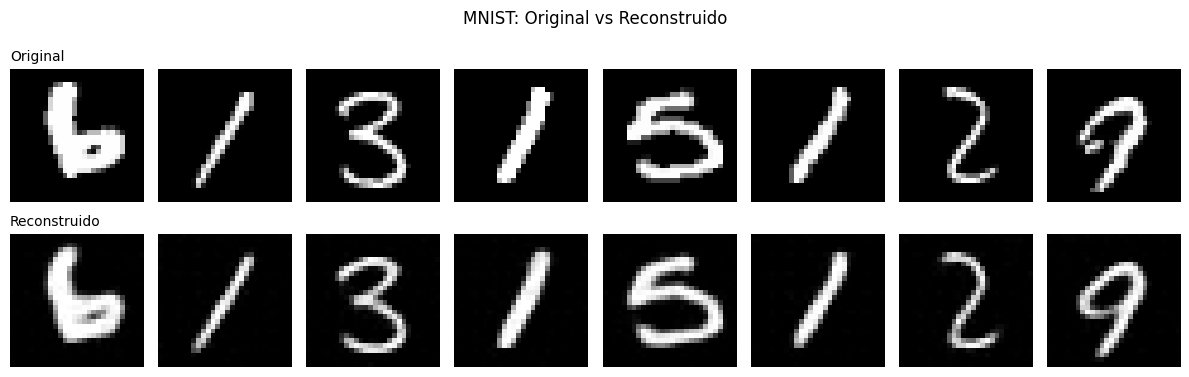

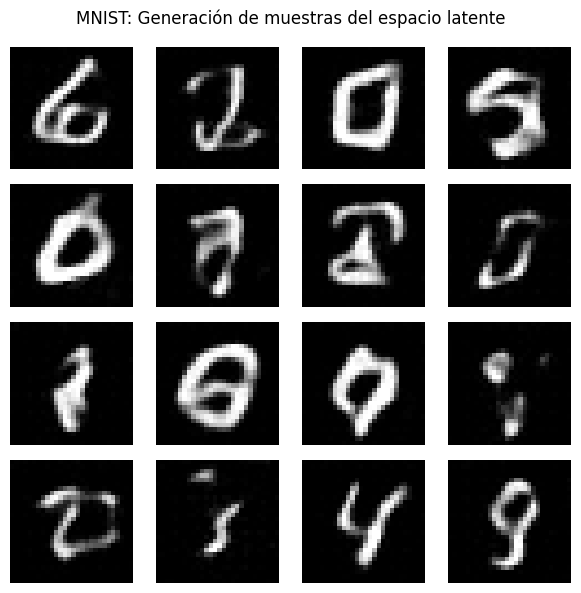

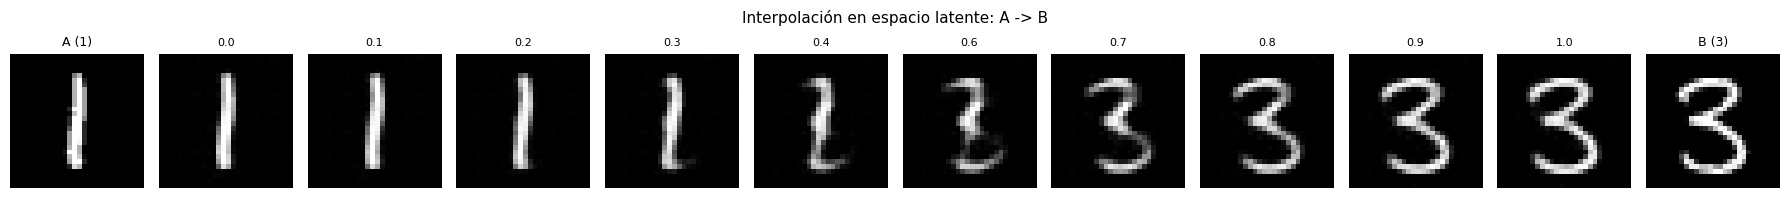

In [34]:
# Cargamos el modelo entrenado
model = VAE_MNIST(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('vae_mnist.pth', map_location=device))
model.eval()

with torch.no_grad():

    test_loader_viz = DataLoader(
        tv.datasets.MNIST(root='./data', train=False, transform=transform_mnist),
        batch_size=8, shuffle=True
    )

    # Reconstrucción de imágenes del MNIST
    images, _ = next(iter(test_loader_viz))
    images = images.to(device)
    recon, _, _ = model(images)

    images_denorm = denormalize_mnist(images).cpu()
    recon_denorm  = denormalize_mnist(recon).cpu()

    fig, axes = plt.subplots(2, 8, figsize=(12, 4))
    for i in range(8):
        axes[0, i].imshow(images_denorm[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_denorm[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_title('Original', fontsize=10, loc='left')
    axes[1, 0].set_title('Reconstruido', fontsize=10, loc='left')
    plt.suptitle('MNIST: Original vs Reconstruido', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Generación de muestras
    latent_samples = torch.randn(16, model.latent_dim).to(device)
    gen_input = model.decoder_input(latent_samples).view(-1, 128, 4, 4)
    generated = denormalize_mnist(model.decoder(gen_input)).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle('MNIST: Generación de muestras del espacio latente', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Interpolación dentro del espacio latente
    test_loader_interp = DataLoader(
        tv.datasets.MNIST(root='./data', train=False, transform=transform_mnist),
        batch_size=2, shuffle=True
    )
    imgs, labels = next(iter(test_loader_interp))
    imgs = imgs.to(device)

    encoded = model.encoder(imgs)
    mu_a = model.encoder_mu(encoded)[0]  # latente de imagen A
    mu_b = model.encoder_mu(encoded)[1]  # latente de imagen B

    # 10 pasos de interpolación: alpha va de 0 (A puro) a 1 (B puro)
    steps = 10
    alphas = torch.linspace(0, 1, steps, device=device)

    interpolated = []
    for alpha in alphas:
        z = (1 - alpha) * mu_a + alpha * mu_b
        z_dec = model.decoder_input(z.unsqueeze(0)).view(-1, 128, 4, 4)
        img_gen = model.decoder(z_dec)
        interpolated.append(denormalize_mnist(img_gen).cpu())

    fig, axes = plt.subplots(1, steps + 2, figsize=(18, 2))

    # Imagen original A
    axes[0].imshow(denormalize_mnist(imgs[0:1]).cpu().squeeze(), cmap='gray')
    axes[0].set_title(f'A ({labels[0].item()})', fontsize=9)
    axes[0].axis('off')

    # Transiciones
    for i, img in enumerate(interpolated):
        axes[i + 1].imshow(img.squeeze(), cmap='gray')
        axes[i + 1].set_title(f'{alphas[i].item():.1f}', fontsize=8)
        axes[i + 1].axis('off')

    # Imagen original B
    axes[-1].imshow(denormalize_mnist(imgs[1:2]).cpu().squeeze(), cmap='gray')
    axes[-1].set_title(f'B ({labels[1].item()})', fontsize=9)
    axes[-1].axis('off')

    plt.suptitle('Interpolación en espacio latente: A -> B', fontsize=11)
    plt.tight_layout()
    plt.show()


#Denoising Diffusion Probabilistic Models (DDPM)

In [7]:
# Configuración del modelo
T          = 300
BETA_START = 1e-4
BETA_END   = 0.02

batch_size_ddpm = 128

In [8]:
# Definición de hipérparámetros
betas      = torch.linspace(BETA_START, BETA_END, T, device=device)
alphas     = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_prev = F.pad(alpha_bars[:-1], (1, 0), value=1.0)

# Términos reutilizados en forward y backward
sqrt_alpha_bars           = alpha_bars.sqrt()
sqrt_one_minus_alpha_bars = (1.0 - alpha_bars).sqrt()
sqrt_recip_alphas         = alphas.rsqrt()

# Varianza posterior
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

print(f'beta_1 = {betas[0]:.5f}  |  beta_T = {betas[-1]:.4f}')
print(f'alpha_bar_1 = {alpha_bars[0]:.4f}  |  alpha_bat_T ≈ {alpha_bars[-1]:.6f}')

beta_1 = 0.00010  |  beta_T = 0.0200
alpha_bar_1 = 0.9999  |  alpha_bat_T ≈ 0.048058


In [9]:
# Función de utilidad para extraer valor de un arreglo.
# Dado un vector a de tamaño T y un batch de índices t (shape B) retorna a[t] con forma (B, 1, 1, 1) para broadcasting con imágenes.

def extract(a, t, x_shape):
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

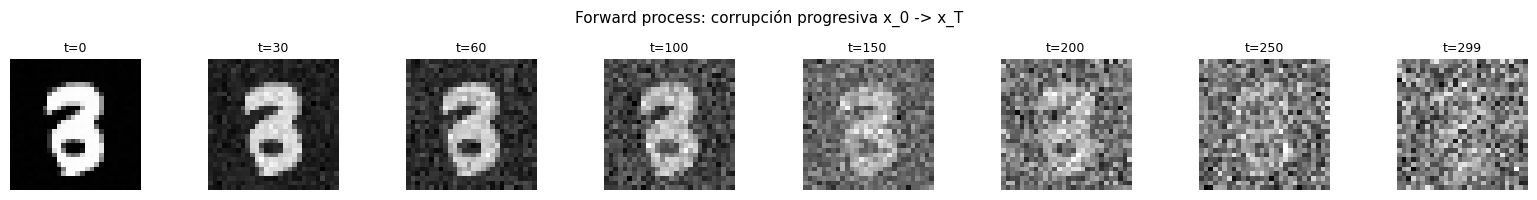

In [36]:
# Forward process
def q_sample(x0, t, noise=None):
    """Corrompe x0 hasta el paso t usando la forma directa del forward process."""
    if noise is None:
        noise = torch.randn_like(x0)
    s_ab  = extract(sqrt_alpha_bars, t, x0.shape)
    s_1ab = extract(sqrt_one_minus_alpha_bars, t, x0.shape)
    return s_ab * x0 + s_1ab * noise, noise


# Visualización del forward process en una sola imagen
with torch.no_grad():

    sample_img, _ = next(iter(DataLoader(
        tv.datasets.MNIST(root='./data', train=False, transform=transform_mnist),
        batch_size=1, shuffle=True
    )))

    sample_img = sample_img.to(device)
    steps_viz  = [0, 30, 60, 100, 150, 200, 250, 299]

    fig, axes = plt.subplots(1, len(steps_viz), figsize=(16, 2))
    for ax, step in zip(axes, steps_viz):
        t_viz = torch.tensor([step], device=device).long()
        x_t, _ = q_sample(sample_img, t_viz)
        ax.imshow(x_t.squeeze().cpu().numpy(), cmap='gray')
        ax.set_title(f't={step}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Forward process: corrupción progresiva x_0 -> x_T', fontsize=11)
    plt.tight_layout()
    plt.show()

In [11]:
# ── Arquitectura: U-Net para predicción de ruido ─────────────────────────
#
# La red ε_φ(x_t, t) estima el ruido ε que fue añadido a x_0.
# La condición de tiempo t se inyecta en cada bloque residual mediante
# Adaptive Group Normalization: la proyección del embedding de t proporciona
# un desplazamiento (bias) que modula los feature maps en cada paso.
#
# Arquitectura:
#   Encoder:     1×28×28  →  64×28×28  →  128×14×14  →  256×7×7
#   Bottleneck:  256×7×7  →  256×7×7
#   Decoder:     256×7×7  →  128×14×14 →  64×28×28   →  1×28×28
#   Skip connections entre encoder y decoder (U-Net estándar)

class SinusoidalTimeEmb(nn.Module):
    """
    Embedding sinusoidal del paso de tiempo t.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    """
    Bloque residual con inyección de embedding de tiempo.
    El embedding de t se proyecta a un sesgo que se suma
    a los feature maps tras la primera normalización.
    """
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        n_groups    = min(8, out_ch)
        self.norm1  = nn.GroupNorm(n_groups, out_ch)
        self.norm2  = nn.GroupNorm(n_groups, out_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(time_dim, out_ch)   # sesgo del tiempo
        self.act    = nn.SiLU()
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.t_proj(t_emb)[:, :, None, None]  # inyección de t
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


class UNet(nn.Module):
    def __init__(self, time_dim=256):
        super().__init__()

        # Embedding de tiempo: sinusoidal → MLP
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Encoder
        self.enc1  = ResBlock(1,   64,  time_dim)
        self.down1 = nn.Conv2d(64,  128, 4, stride=2, padding=1)  # 28→14
        self.enc2  = ResBlock(128, 128, time_dim)
        self.down2 = nn.Conv2d(128, 256, 4, stride=2, padding=1)  # 14→7
        self.enc3  = ResBlock(256, 256, time_dim)

        # Bottleneck
        self.mid = ResBlock(256, 256, time_dim)

        # Decoder (skip connections desde el encoder)
        self.up1  = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)  # 7→14
        self.dec1 = ResBlock(256, 128, time_dim)   # 256 = 128 (up) + 128 (skip enc2)
        self.up2  = nn.ConvTranspose2d(128,  64, 4, stride=2, padding=1)  # 14→28
        self.dec2 = ResBlock(128,  64, time_dim)   # 128 = 64  (up) +  64 (skip enc1)

        self.out  = nn.Conv2d(64, 1, 1)            # proyección final a canal de imagen

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        e1 = self.enc1(x, t_emb)                            # 64×28×28
        e2 = self.enc2(self.down1(e1), t_emb)               # 128×14×14
        e3 = self.enc3(self.down2(e2), t_emb)               # 256×7×7

        b  = self.mid(e3, t_emb)                            # 256×7×7

        d1 = self.dec1(torch.cat([self.up1(b),  e2], dim=1), t_emb)  # 128×14×14
        d2 = self.dec2(torch.cat([self.up2(d1), e1], dim=1), t_emb)  # 64×28×28

        return self.out(d2)                                  # 1×28×28

In [12]:
# Pérdida simplificada o Simple Loss
def p_losses(model, x0, t):
    noise        = torch.randn_like(x0)
    x_noisy, _   = q_sample(x0, t, noise)
    pred_noise   = model(x_noisy, t)
    return F.mse_loss(pred_noise, noise)

In [13]:
# Entrenamiento
ddpm_model = UNet().to(device)
ddpm_opt   = optim.Adam(ddpm_model.parameters(), lr=2e-4)

train_loader_ddpm = DataLoader(
    tv.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist),
    batch_size=batch_size_ddpm, shuffle=True, num_workers=2, pin_memory=True
)

num_epochs_ddpm = 15
ddpm_model.train()
print(f'Entrenando DDPM por {num_epochs_ddpm} epochs  |  T={T}  |  {device}')

for epoch in range(num_epochs_ddpm):
    epoch_loss = 0.0
    for images, _ in train_loader_ddpm:
        images = images.to(device)
        # Muestrear t ~ U{1,...,T} para cada imagen del batch
        t = torch.randint(0, T, (images.shape[0],), device=device).long()

        ddpm_opt.zero_grad()
        loss = p_losses(ddpm_model, images, t)
        loss.backward()
        # Clip de gradientes para estabilidad
        torch.nn.utils.clip_grad_norm_(ddpm_model.parameters(), 1.0)
        ddpm_opt.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader_ddpm)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:>2}/{num_epochs_ddpm}]  L_simple: {avg:.5f}')

print('\nEntrenamiento DDPM completado')

Entrenando DDPM por 15 epochs  |  T=300  |  cuda:0
Epoch [ 1/15]  L_simple: 0.09508
Epoch [ 5/15]  L_simple: 0.05455
Epoch [10/15]  L_simple: 0.05163
Epoch [15/15]  L_simple: 0.05006

Entrenamiento DDPM completado


In [35]:
# Guardamos el modelo
torch.save(ddpm_model.state_dict(), 'ddpm_mnist.pth')

In [37]:
# Backward process

@torch.no_grad()
def p_sample_step(model, x, t_idx):
    """Un paso del proceso inverso: p_φ(x_{t-1} | x_t)."""
    t = torch.full((x.shape[0],), t_idx, device=device, dtype=torch.long)

    betas_t       = extract(betas, t, x.shape)
    sqrt_1ab_t    = extract(sqrt_one_minus_alpha_bars, t, x.shape)
    sqrt_rec_a_t  = extract(sqrt_recip_alphas, t, x.shape)

    pred_noise = model(x, t)

    # Media estimada
    mean = sqrt_rec_a_t * (x - betas_t * pred_noise / sqrt_1ab_t)

    if t_idx == 0:
        return mean  # último paso: sin ruido adicional

    post_var = extract(posterior_variance, t, x.shape)
    return mean + torch.sqrt(post_var) * torch.randn_like(x)


@torch.no_grad()
def generate(model, n_samples=16):
    """
    Muestreo completo del backward process.
    Comienza con x_T ~ N(0,I) y aplica T pasos inversos hasta x_0.
    """
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)  # x_T ~ p_prior
    for t_idx in reversed(range(T)):                       # t = T-1, ..., 0
        x = p_sample_step(model, x, t_idx)
    return x.cpu()

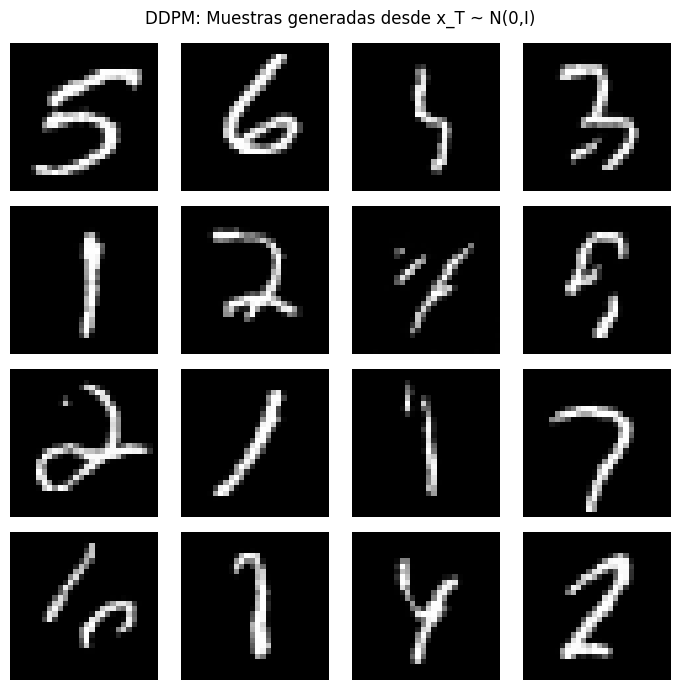

In [38]:
# Generación de muestras en conjunto

ddpm_model = UNet().to(device)
ddpm_model.load_state_dict(torch.load('ddpm_mnist.pth', map_location=device))

samples       = generate(ddpm_model, n_samples=16)
samples_denorm = denormalize_mnist(samples.to(device)).cpu()

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples_denorm[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('DDPM: Muestras generadas desde x_T ~ N(0,I)', fontsize=12)
plt.tight_layout()
plt.show()

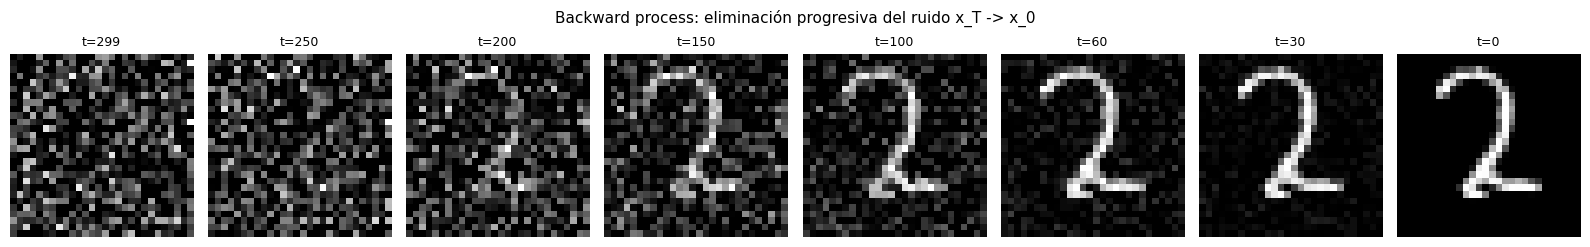

In [44]:
# Visualización del backward process paso a paso
# Muestra cómo el modelo elimina el ruido paso a paso desde x_T hasta x_0

@torch.no_grad()
def generate_with_trajectory(model, steps_to_save):
    """Igual que generate() pero guarda x_t en los pasos indicados."""
    model.eval()
    x = torch.randn(1, 1, 28, 28, device=device)
    trajectory = {}
    for t_idx in reversed(range(T)):
        x = p_sample_step(model, x, t_idx)
        if t_idx in steps_to_save:
            trajectory[t_idx] = x.clone().cpu()
    return trajectory

steps_viz  = [299, 250, 200, 150, 100, 60, 30, 0]
trajectory = generate_with_trajectory(ddpm_model, set(steps_viz))

fig, axes = plt.subplots(1, len(steps_viz), figsize=(16, 2.5))
for ax, step in zip(axes, steps_viz):
    img = denormalize_mnist(trajectory[step].to(device)).cpu()
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f't={step}', fontsize=9)
    ax.axis('off')
plt.suptitle('Backward process: eliminación progresiva del ruido x_T -> x_0', fontsize=11)
plt.tight_layout()
plt.show()